# FD001 Final Error Analysis

This notebook reads the frozen Module 9 artifacts. It does not retune the model or modify final-test evidence.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

predictions = pd.read_csv(Path('../reports/final-test-predictions.csv'))
metrics = json.loads(Path('../reports/final-evaluation.json').read_text())
predictions.head()

,unit_id,cycle,official_raw_rul,target_rul,raw_prediction,predicted_rul,error
0,1,31,112,112.0,118.946007,118.946007,6.946007
1,2,49,98,98.0,125.751823,125.000000,27.000000
2,3,126,69,69.0,44.498123,44.498123,-24.501877
3,4,106,82,82.0,71.376015,71.376015,-10.623985
4,5,98,91,91.0,86.592804,86.592804,-4.407196


In [2]:
predictions['absolute_error'] = predictions['error'].abs()
predictions['true_rul_band'] = pd.cut(
    predictions['target_rul'],
    bins=[-1, 30, 60, float('inf')],
    labels=['0-30', '31-60', '>60'],
)
predictions.groupby('true_rul_band', observed=True)['absolute_error'].agg(['count', 'mean'])

,count,mean
true_rul_band,,
0-30,25,4.533754
31-60,14,7.143855
>60,61,13.599230


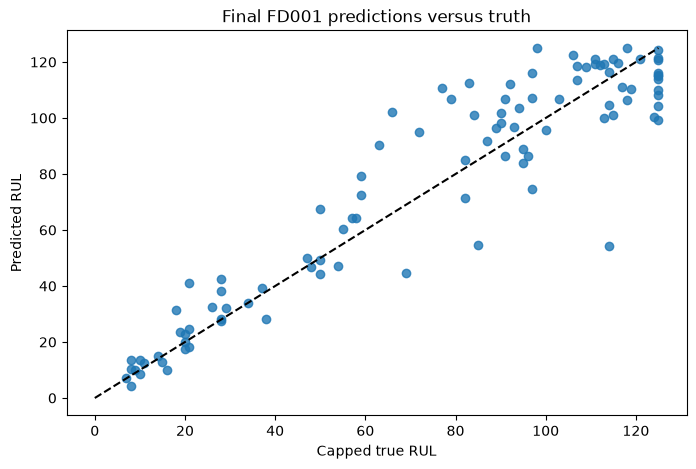

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(predictions['target_rul'], predictions['predicted_rul'], alpha=0.8)
plt.plot([0, 125], [0, 125], linestyle='--', color='black')
plt.xlabel('Capped true RUL')
plt.ylabel('Predicted RUL')
plt.title('Final FD001 predictions versus truth')
plt.show()

## Explainability note

The global and local SHAP artifacts are in `reports/final-explainability/`. SHAP describes model behavior for these rows; it does not establish physical sensor causality.